In [1]:
import pandas as pd
# Carregar o arquivo CSV
df = pd.read_csv('googleplaystore.csv')
linhas_antes = df.shape[0]
# Remover linhas duplicadas
df = df.drop_duplicates()
linhas_depois = df.shape[0]
# Salvar o arquivo CSV sem duplicatas
df.to_csv('googleplaystore_sem_duplicatas.csv', index=False)
print("Linhas duplicadas removidas e arquivo salvo como 'googleplaystore_limp.csv'")


Linhas duplicadas removidas e arquivo salvo como 'googleplaystore_limp.csv'


In [6]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


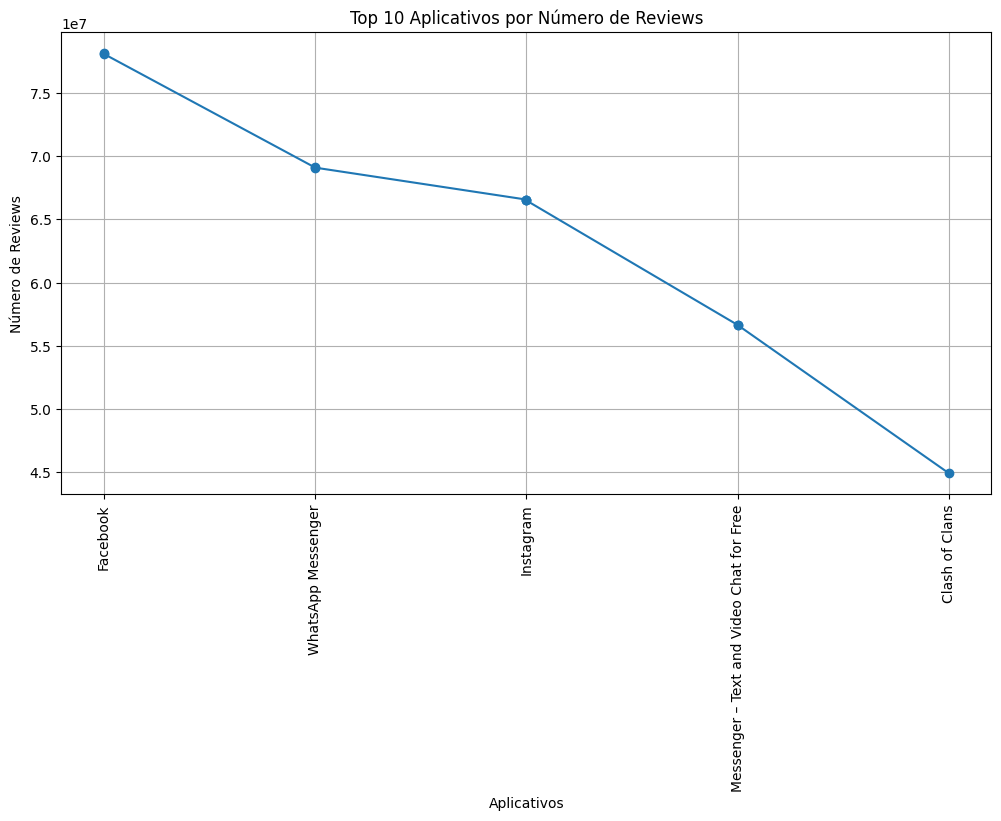

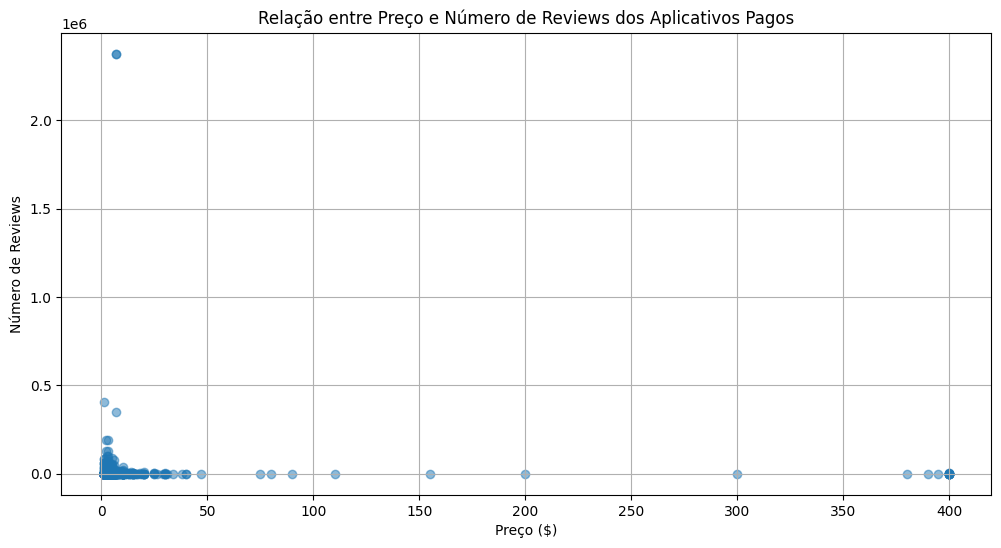

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar o arquivo CSV
df = pd.read_csv('googleplaystore_sem_duplicatas.csv')

# Converter a coluna 'Reviews' para numérico
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Remover linhas com valores NaN na coluna 'Reviews'
df = df.dropna(subset=['Reviews'])

# Ordenar os aplicativos pelo número de reviews em ordem decrescente
df_sorted_reviews = df.sort_values(by='Reviews', ascending=False)

# Selecionar os top 10 aplicativos por número de reviews
top_10_apps_reviews = df_sorted_reviews.head(10)

# Gráfico de Linhas para os top 10 aplicativos por número de reviews
plt.figure(figsize=(12, 6))
plt.plot(top_10_apps_reviews['App'], top_10_apps_reviews['Reviews'], marker='o')
plt.xticks(rotation=90)
plt.xlabel('Aplicativos')
plt.ylabel('Número de Reviews')
plt.title('Top 10 Aplicativos por Número de Reviews')
plt.grid(True)
plt.show()

# Converter a coluna 'Price' para numérico, removendo o símbolo de dólar
df['Price'] = df['Price'].str.replace('$', '').astype(float, errors='ignore')

# Filtrar apenas os aplicativos pagos e com preço não nulo
df_paid = df[(df['Type'] == 'Paid') & (df['Price'].notna())]

# Gráfico de Dispersão para mostrar a relação entre o preço e o número de reviews dos aplicativos pagos
plt.figure(figsize=(12, 6))
plt.scatter(df_paid['Price'], df_paid['Reviews'], alpha=0.5)
plt.xlabel('Preço ($)')
plt.ylabel('Número de Reviews')
plt.title('Relação entre Preço e Número de Reviews dos Aplicativos Pagos')
plt.grid(True)
plt.show()
